# Head

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

# proj_dir = Path.home() / "zqlyu"/ "projects" / "MolScanner"
proj_dir = Path.home() / "projects" / "Markush"
data_dir = proj_dir / "data"

# Model

In [3]:
from MolScribe_re_model import MolScannerVocab
vocab = MolScannerVocab(n_bins=64)
print(len(vocab))

207


In [4]:
from MolScribe_re_model import MolScribeModel
model = MolScribeModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = 'best'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScribe_re_1M_synthetic" / f"{checkpoint}.pth"), device='cuda')

Model loaded from: /home/zqlyu2/projects/Markush/MolScanner/models/MolScribe_re_1M_synthetic/best.pth


# Functions for SMILES pre-/post-preocessing

In [5]:
from rdkit import Chem

def remove_atom_mapping(smiles: str) -> str:
    """去除 SMILES 中的原子映射编号"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)

# Synthetic samples

## Data

In [6]:
import pickle

with open(data_dir / "pubchem_smiles/pubchem_smile_list.pkl", "rb") as f:
    pubchem_smile_list = pickle.load(f)

In [7]:
from MolScribe_re_model import MoleculeDataset
dataset = MoleculeDataset(vocab, pubchem_smile_list, 
                          shuffle_smiles=False, 
                          mol_augment=True,
                          geo_augment=True,
                          img_augment=True,
                          default_drawing_style=False)

## Input

torch.Size([3, 384, 384])
tensor(2.6400)


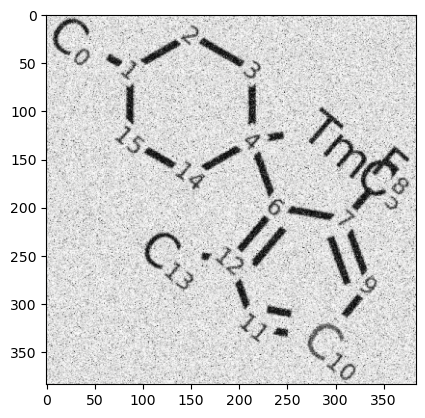

sequence length: 67
[1, 6, 82, 146, 6, 93, 152, 57, 6, 104, 146, 6, 114, 152, 6, 114, 164, 68, 66, 23, 42, 18, 67, 126, 162, 69, 68, 6, 118, 176, 58, 6, 130, 178, 68, 9, 138, 169, 69, 70, 6, 134, 189, 6, 126, 199, 70, 6, 114, 197, 6, 110, 185, 70, 58, 6, 98, 183, 69, 6, 103, 170, 6, 93, 164, 57, 2]
['<SOS>', 'C', '<X_BIN_3>', '<Y_BIN_3>', 'C', '<X_BIN_14>', '<Y_BIN_9>', '1', 'C', '<X_BIN_25>', '<Y_BIN_3>', 'C', '<X_BIN_35>', '<Y_BIN_9>', 'C', '<X_BIN_35>', '<Y_BIN_21>', '(', '[', 'T', 'm', 'O', ']', '<X_BIN_47>', '<Y_BIN_19>', ')', '(', 'C', '<X_BIN_39>', '<Y_BIN_33>', '2', 'C', '<X_BIN_51>', '<Y_BIN_35>', '(', 'F', '<X_BIN_59>', '<Y_BIN_26>', ')', '=', 'C', '<X_BIN_55>', '<Y_BIN_46>', 'C', '<X_BIN_47>', '<Y_BIN_56>', '=', 'C', '<X_BIN_35>', '<Y_BIN_54>', 'C', '<X_BIN_31>', '<Y_BIN_42>', '=', '2', 'C', '<X_BIN_19>', '<Y_BIN_40>', ')', 'C', '<X_BIN_24>', '<Y_BIN_27>', 'C', '<X_BIN_14>', '<Y_BIN_21>', '1', '<EOS>']
bond matrix shape: (16, 16)
[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 

In [8]:
import random
 
sample = dataset[random.randint(0, len(dataset)-1)] 

from matplotlib import pyplot as plt
import torch

img_tensor = sample['img'] # [3, H, W]
print(img_tensor.shape)
print(img_tensor.max())

def denormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    img_tensor = img_tensor.clamp(0, 1) * 255.0
    return img_tensor.byte()

img_denorm = denormalize_img(img_tensor)

plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.show()

print("sequence length:", len(sample['tok_id_seq']))
print(sample['tok_id_seq'])
print([vocab.idx2token[idx] for idx in sample['tok_id_seq']])
print("bond matrix shape:", sample['bond_mat'].shape)
print(sample['bond_mat'])
print(vocab.sequence_to_smiles(sample['tok_id_seq']))

## Predicton

In [9]:
import numpy as np

result_post = model.predict(sample['img'], device='cuda', beam_size=1)
print("sequence length:", len(result_post['token_ids']))
print(result_post['token_ids'])
print(result_post['smiles'])
print("atom number:", len(result_post['symbols']))
print("symbols:", result_post['symbols'])
print("bond matrix shape:", result_post['bond_mat'].shape)
print(result_post['bond_mat'])
is_symmetric = np.allclose(result_post['bond_mat'], result_post['bond_mat'].T)
print(f"Bond marix is symmetric: {is_symmetric}")

print(result_post['success'])

result_decoder = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="decoder")
result_graph = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="graph")

sequence length: 67
[1, 6, 82, 146, 6, 93, 152, 57, 6, 103, 146, 6, 114, 152, 6, 114, 164, 68, 66, 23, 42, 6, 67, 126, 162, 69, 68, 6, 118, 176, 58, 6, 130, 178, 68, 9, 138, 169, 69, 70, 6, 134, 189, 6, 127, 199, 70, 6, 115, 197, 6, 110, 185, 70, 58, 6, 98, 183, 69, 6, 104, 171, 6, 93, 164, 57, 2]
CC1CCC([TmC])(C2C(F)=CC=CC=2C)CC1
atom number: 16
symbols: ['C', 'C', 'C', 'C', 'C', '[TmC]', 'C', 'C', 'F', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
bond matrix shape: (16, 16)
[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 1 0 1 2 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 1 0 0 0]
 [0 0 0 0 0 0 2 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 

Groundtruth SMILES:
 CC1CCC([TmO])(C2C(F)=CC=CC=2C)CC1
Decoder SMILES:
 CC1CCC([TmC])(C2C(F)=CC=CC=2C)CC1
Graph SMILES:
 CC1CCC([TmC])(C2C(F)=CC=CC=2C)CC1
Postprocess SMILES:
 CC1CCC([TmC])(C2C(F)=CC=CC=2C)CC1

Canonical Groundtruth SMILES:
 *C1(c2c(C)cccc2F)CCC(C)CC1
Canonical Postprocess SMILES:
 *C1(c2c(C)cccc2F)CCC(C)CC1
Canonical SMILES match: True


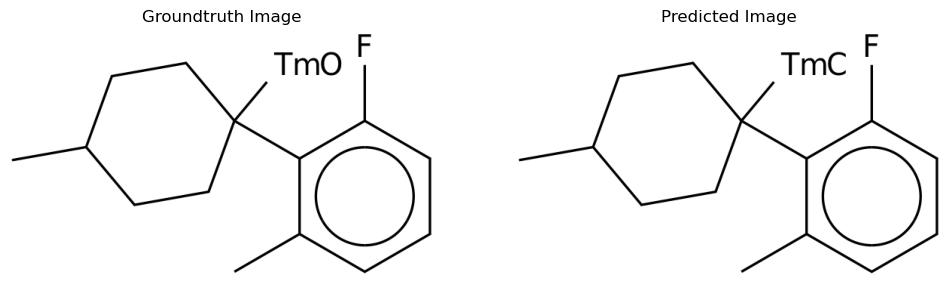

In [10]:
from drawing_engine import generate_image_from_graph
from chemistry import canonicalize_smiles

smiles_gt = vocab.sequence_to_smiles(sample['tok_id_seq'])['smiles']
print("Groundtruth SMILES:\n", smiles_gt)
symbols = vocab.sequence_to_smiles(sample['tok_id_seq'])['symbols']
coords = vocab.sequence_to_smiles(sample['tok_id_seq'])['coords']
img_gt, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': sample['bond_mat']}, debug=True)

smiles_decoder = result_decoder['smiles']
print("Decoder SMILES:\n", smiles_decoder)
smiles_graph = result_graph['smiles']
print("Graph SMILES:\n", smiles_graph)
smiles_post = result_post['smiles']
print("Postprocess SMILES:\n", smiles_post)

symbols = result_post['symbols']
coords = result_post['coords']
img_pred, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': result_post['bond_mat']}, debug=False)

smiles_gt_canonical, _ = canonicalize_smiles(remove_atom_mapping(smiles_gt))
smiles_pred_canonical,_  = canonicalize_smiles(remove_atom_mapping(smiles_post))
print("\nCanonical Groundtruth SMILES:\n", smiles_gt_canonical)
print("Canonical Postprocess SMILES:\n", smiles_pred_canonical)
print("Canonical SMILES match:", smiles_gt_canonical == smiles_pred_canonical)

from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gt, cmap='gray')
axes[0].set_title('Groundtruth Image')
axes[0].axis('off')

axes[1].imshow(img_pred, cmap='gray')
axes[1].set_title('Predicted Image')
axes[1].axis('off')
plt.show()

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

gt_mol = Chem.MolFromSmiles(smiles_gt_canonical)
pred_mol = Chem.MolFromSmiles(smiles_pred_canonical)

if gt_mol and pred_mol:
    gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, 2, nBits=1024)
    pred_fp = AllChem.GetMorganFingerprintAsBitVect(pred_mol, 2, nBits=1024)
    tanimoto = DataStructs.TanimotoSimilarity(gt_fp, pred_fp)
    print(f"Tanimoto Similarity: {tanimoto}")
else:
    print("Invalid SMILES")

Tanimoto Similarity: 1.0


# USPTO 680K Dataset

## Data

In [136]:
import importlib
import MolScribe_re_model
importlib.reload(MolScribe_re_model)
from MolScribe_re_model import USPTOMolDataset

uspto_csv = str(data_dir / "uspto_mol" / "train_680k.csv")
uspto_dir = str(data_dir)  # file_path in CSV is relative to data/

uspto_dataset = USPTOMolDataset(
    vocab, 
    csv_path=uspto_csv,
    data_dir=uspto_dir,
    img_augment=True,
    geo_augment=True,
)
print(f"USPTO dataset size: {len(uspto_dataset)}")

# Use the filtered dataframe from the dataset (not the raw CSV)
df = uspto_dataset.df
display(df.head(3))

[USPTOMolDataset] Filtered 244239/680220 rows with non-vocab SMILES chars (35.9%)
USPTO dataset size: 435981


,file_path,mol_path,raw_SMILES,SMILES,node_coords,edges
0,/home/zqlyu2/projects/Markush/data/uspto_mol/2...,uspto_mol/2008/I20080429/US07364824-20080429/U...,C=CC(=O)OCCOC1=CC(OCCOC(=O)C=C)=CC(N(C2=CC=C(C...,C=CC(=O)OCCOC1=CC(OCCOC(=O)C=C)=CC(N(C2=CC=C(C...,"[[6.7569,2.6208],[5.6804,2.6208],[4.8554,2.620...","[[11,10,1],[10,19,2],[19,20,1],[20,41,2],[41,8..."
1,/home/zqlyu2/projects/Markush/data/uspto_mol/2...,uspto_mol/2008/I20080902/US07419988-20080902/U...,CCN1C=C(/C2=C/C=N\C3=C2C=CN3)C(C2=CC=C(NC(=O)N...,CCN1C=C(/C2=C/C=N\C3=C2C=CN3)C(C2=CC=C(NC(=O)N...,"[[4.1667,-0.2028],[3.7542,0.5117],[2.9292,0.51...","[[22,20,1],[20,19,1],[19,18,1],[18,17,2],[17,1..."
2,/home/zqlyu2/projects/Markush/data/uspto_mol/2...,uspto_mol/2006/I20060328/US07018981-20060328/U...,CN1CCC[C@H](N(C)C(=O)[C@@H](N)CC2=CC=C(F)C=C2)...,CN1CCC[C@H](N(C)C(=O)[C@@H](N)CC2=CC=C(F)C=C2)...,"[[1.0717,-3.0937],[1.0717,-2.2688],[0.3572,-1....","[[17,16,1],[16,18,1],[18,19,2],[19,13,1],[13,1..."


## Input

Image tensor shape: torch.Size([3, 384, 384])


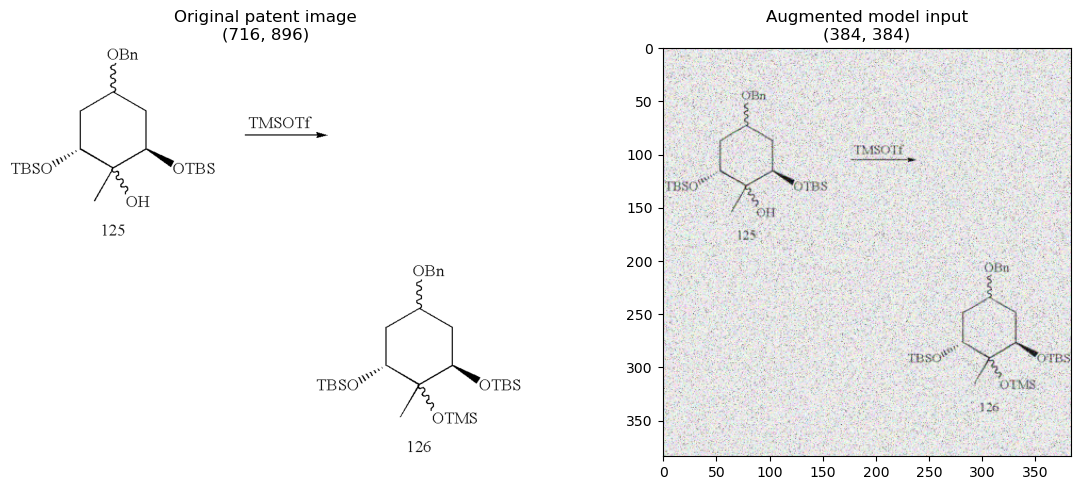


Sequence length: 354
Token IDs: [1, 6, 91, 598, 6, 105, 573, 57, 68, 18, 120, 598, 69, 66, 6, 72, 11, 67, 80, 559, 68, 18, 80, 559, 66, 22, 38, 67, 105, 573, 68, 6, 91, 598, 69, 68, 6, 131, 587, 69, 6, 120, 549, 68, 6, 146, 563, 69, 68, 6, 95, 535, 69, 6, 135, 524, 69, 6, 80, 531, 6, 105, 517, 68, 18, 120, 503, 6, 135, 527, 6, 165, 527, 58, 70, 6, 179, 552, 6, 209, 552, 70, 6, 224, 527, 6, 209, 503, 70, 6, 179, 503, 58, 69, 6, 131, 531, 66, 6, 72, 11, 67, 131, 559, 57, 18, 157, 573, 66, 22, 38, 67, 157, 602, 68, 6, 157, 630, 69, 68, 6, 127, 602, 69, 6, 186, 602, 68, 6, 186, 573, 69, 68, 6, 216, 602, 69, 6, 186, 630, 77, 6, 328, 759, 6, 343, 734, 57, 68, 18, 358, 759, 66, 22, 38, 67, 343, 783, 68, 6, 369, 797, 69, 68, 6, 328, 808, 69, 6, 318, 769, 69, 66, 6, 72, 11, 67, 369, 720, 68, 18, 394, 734, 66, 22, 38, 67, 394, 762, 68, 6, 394, 791, 69, 68, 6, 365, 762, 69, 6, 424, 762, 68, 6, 424, 734, 69, 68, 6, 454, 762, 69, 6, 424, 791, 69, 6, 369, 692, 6, 343, 678, 68, 18, 358, 663, 6, 373,

In [141]:
import random
import torch
import numpy as np
from matplotlib import pyplot as plt
import cv2

idx = random.randint(0, len(uspto_dataset) - 1)
sample = uspto_dataset[idx]
while not sample['success']:
    idx = random.randint(0, len(uspto_dataset) - 1)
    sample = uspto_dataset[idx]

img_tensor = sample['img']  # [3, H, W]
print("Image tensor shape:", img_tensor.shape)

def denormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    return img_tensor.clamp(0, 1).byte() if img_tensor.max() > 1 else img_tensor.clamp(0, 1)

# Show original patent image for comparison (same molecule)
row = df.iloc[idx]
orig_path = str(data_dir / row['file_path'])
orig_img = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB) if cv2.imread(orig_path) is not None else None

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if orig_img is not None:
    axes[0].imshow(orig_img)
    axes[0].set_title(f'Original patent image\n{orig_img.shape[:2]}')
else:
    axes[0].set_title('(could not load)')
axes[0].axis('off')

img_denorm = denormalize_img(img_tensor)
if img_denorm.dtype == torch.float32:
    axes[1].imshow(img_denorm.permute(1, 2, 0).numpy())
else:
    axes[1].imshow(img_denorm.permute(1, 2, 0).numpy())
axes[1].set_title(f'Augmented model input\n{tuple(img_tensor.shape[1:])}')
# axes[1].axis('off')
plt.tight_layout()
plt.show()

print("\nSequence length:", len(sample['tok_id_seq']))
print("Token IDs:", sample['tok_id_seq'])
print("Tokens:", [vocab.idx2token[idx] for idx in sample['tok_id_seq']])
print("Bond matrix shape:", sample['bond_mat'].shape)
print("SMILES:", sample['smiles'])

## Prediction

In [ ]:
result_post = model.predict(sample['img'], device='cuda', beam_size=1)
print("Predicted sequence length:", len(result_post['token_ids']))
print("Predicted SMILES:", result_post['smiles'])
print("Atom count:", len(result_post['symbols']))
print("Bond matrix shape:", result_post['bond_mat'].shape)
print("Success:", result_post['success'])

result_decoder = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="decoder")
result_graph = model.predict(sample['img'], device='cuda', beam_size=1, smiles_mode="graph")

In [ ]:
from drawing_engine import generate_image_from_graph
from chemistry import canonicalize_smiles

# Ground truth from dataset
gt_info = vocab.sequence_to_smiles(sample['tok_id_seq'])
smiles_gt = gt_info['smiles']
print("Ground truth SMILES:\n", smiles_gt)
symbols_gt = gt_info['symbols']
coords_gt = gt_info['coords']
img_gt, _, _, success_gt = generate_image_from_graph(
    {'symbols': symbols_gt, 'coords': coords_gt, 'edges': sample['bond_mat']}, debug=True
)

# Prediction
smiles_decoder = result_decoder['smiles']
print("Decoder SMILES:\n", smiles_decoder)
smiles_graph = result_graph['smiles']
print("Graph SMILES:\n", smiles_graph)
smiles_post = result_post['smiles']
print("Postprocess SMILES:\n", smiles_post)

symbols_pred = result_post['symbols']
coords_pred = result_post['coords']
img_pred, _, _, success_pred = generate_image_from_graph(
    {'symbols': symbols_pred, 'coords': coords_pred, 'edges': result_post['bond_mat']}, debug=False
)

smiles_gt_canonical, _ = canonicalize_smiles(remove_atom_mapping(smiles_gt))
smiles_pred_canonical, _ = canonicalize_smiles(remove_atom_mapping(smiles_post))
print("\nCanonical GT SMILES:\n", smiles_gt_canonical)
print("Canonical Pred SMILES:\n", smiles_pred_canonical)
print("Match:", smiles_gt_canonical == smiles_pred_canonical)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

img_denorm = denormalize_img(sample['img'])
if img_denorm.dtype == torch.float32:
    axes[0].imshow(img_denorm.permute(1, 2, 0).numpy())
else:
    axes[0].imshow(img_denorm.permute(1, 2, 0).numpy())
axes[0].set_title('Model input (augmented)')
axes[0].axis('off')

axes[1].imshow(img_gt, cmap='gray')
axes[1].set_title('GT (from graph)')
axes[1].axis('off')

axes[2].imshow(img_pred, cmap='gray')
axes[2].set_title('Predicted (from graph)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

gt_mol = Chem.MolFromSmiles(smiles_gt_canonical)
pred_mol = Chem.MolFromSmiles(smiles_pred_canonical)

if gt_mol and pred_mol:
    gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, 2, nBits=1024)
    pred_fp = AllChem.GetMorganFingerprintAsBitVect(pred_mol, 2, nBits=1024)
    tanimoto = DataStructs.TanimotoSimilarity(gt_fp, pred_fp)
    print(f"Tanimoto Similarity: {tanimoto}")
else:
    print("Invalid SMILES — cannot compute similarity")

# Benchmark

In [12]:
import pandas as pd
from IPython.display import display

benchmark_type = 'real'
benchmark_name = 'staker'
benchmark_dir = data_dir / "benchmark" / benchmark_type / benchmark_name

with open(data_dir / 'benchmark' / benchmark_type / f'{benchmark_name}.csv') as f:
    label_df = pd.read_csv(f)
display(label_df)

,image_id,file_path,SMILES
0,0,real/staker/0.png,CC(C)(C)OC(=O)[C@@H]1C[C@]2(CN1)CN(C(=O)O2)C1C...
1,1,real/staker/1.png,CC(C)(C)[C@@H](N)C(=O)N1C[C@]2(C[C@@H]1C(=O)OC...
2,2,real/staker/2.png,CC(C)(C)OC(=O)[C@@H]1C[C@@]2(CN1)CN(C(=O)O2)C1...
3,3,real/staker/3.png,FC1=C2C(=NNC2=CC=C1C1C=C(CN2CCCCC2)C=NC=1)C1NC...
4,4,real/staker/4.png,FC1=C2C(=NNC2=CC=C1C1C=C(CN2CCCC2)C=NC=1)C1NC2...
...,...,...,...
49995,49995,real/staker/49995.png,CCCCCNS(=O)(=O)C1C=CC(F)=CC=1
49996,49996,real/staker/49996.png,CCCCCCCCCNC(=O)C1C=CC=CC=1
49997,49997,real/staker/49997.png,CC[Si](CC)(CC)C#CC1=NC(Cl)=CN=C1N
49998,49998,real/staker/49998.png,COCCOCCOCC(=O)NC1=CC=CC=C1N


## Reload the model

In [13]:
from MolScribe_re_model import MolScribeModel

model = MolScribeModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = 'best'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScribe_re_1M_synthetic"/ f"{checkpoint}.pth"), device='cuda')

Model loaded from: /home/zqlyu2/projects/Markush/MolScanner/models/MolScribe_re_1M_synthetic/best.pth


## Single

### Prediction

input image size: (256, 256, 3)
0 255 uint8


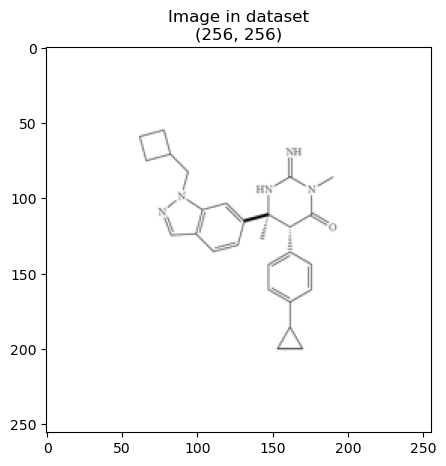

Original Ground truth SMILES: CN1C(=N)N[C@@](C)([C@H](C1=O)C1=CC=C(C=C1)C1CC1)C1C=CC2C=NN(CC3CCC3)C=2C=1
Ground truth SMILES canonicalization successful: True
tensor(-2.0665) tensor(2.6400) torch.float32
output token_id sequence length: 141
Predicted atom symbols: ['C', '[C@]', 'C', 'C', 'C', 'C', 'C', 'N', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'C', 'N', 'N', 'C', 'C', 'O', '[C@H]', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
Predicted bond matrix is symmetric: False
Predicted image generation successful: True


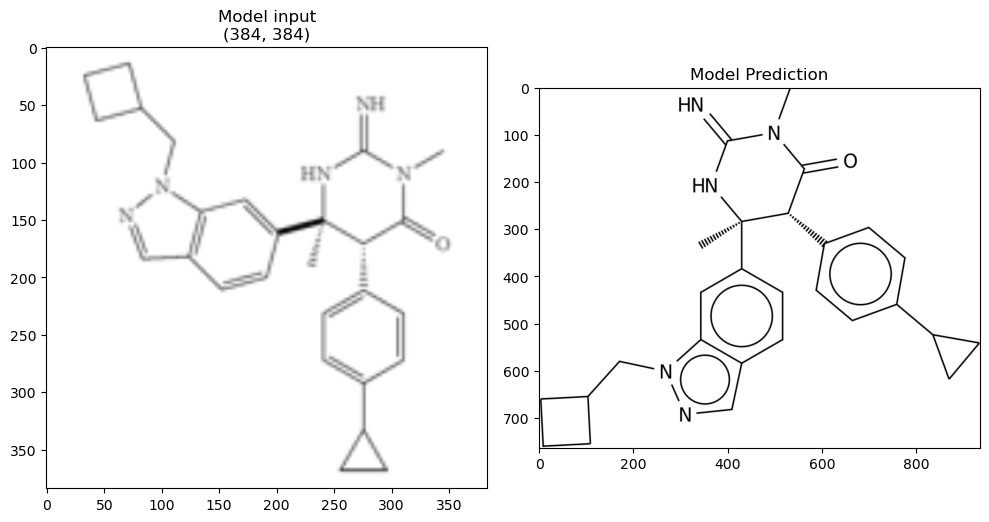

Predicted SMILES:
 CN1C(=N)N[C@](C)(c2ccc3cnn(CC4CCC4)c3c2)[C@@H](c2ccc(C3CC3)cc2)C1=O
Predicted SMILES canonicalization successful: True
Ground Truth: CN1C(=N)N[C@](C)(c2ccc3cnn(CC4CCC4)c3c2)[C@@H](c2ccc(C3CC3)cc2)C1=O
Predicted:    CN1C(=N)N[C@](C)(c2ccc3cnn(CC4CCC4)c3c2)[C@@H](c2ccc(C3CC3)cc2)C1=O
Match: True


In [17]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from drawing_engine import generate_image_from_graph
from chemistry import _convert_graph_to_smiles
from chemistry import canonicalize_smiles
import cv2

random_row = label_df.sample(n=1).iloc[0]
img_id = random_row['image_id']
random_png = benchmark_dir / f"{img_id}.png"
print("input image size:", cv2.imread(str(random_png)).shape)
print(cv2.imread(str(random_png)).min(), cv2.imread(str(random_png)).max(), cv2.imread(str(random_png)).dtype)

# Original image in dataset
fig1, ax1 = plt.subplots(figsize=(5, 5))
ax1.imshow(cv2.cvtColor(cv2.imread(str(random_png)), cv2.COLOR_BGR2RGB))
ax1.set_title(f'Image in dataset\n{cv2.imread(str(random_png)).shape[:2]}')
# ax1.axis('off')
plt.show()

# Ground truth SMILES
raw_ground_truth_smiles = random_row['SMILES']
print("Original Ground truth SMILES:", raw_ground_truth_smiles)
ground_truth_smiles = remove_atom_mapping(raw_ground_truth_smiles)
ground_truth_smiles, success = canonicalize_smiles(ground_truth_smiles, ignore_cistrans=True)
print("Ground truth SMILES canonicalization successful:", success)

result_post = model.predict(str(random_png), device='cuda', beam_size=1, return_preprocessed=True)

print(result_post['preprocessed_img'].min(), result_post['preprocessed_img'].max(), result_post['preprocessed_img'].dtype)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# 反归一化用于显示
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
img_display = result_post['preprocessed_img'] * std[:, None, None] + mean[:, None, None]
img_display = img_display.permute(1, 2, 0).numpy()
img_display = np.clip(img_display, 0, 1)
axes[0].imshow(img_display)
axes[0].set_title(f'Model input\n{img_display.shape[:2]}')
# axes[0].axis('off')

print("output token_id sequence length:", len(result_post['token_ids']))
# New format: [symbol, x, y, symbol, x, y, ...]
symbols = result_post['symbols']
coords = result_post['coords']
print("Predicted atom symbols:", symbols)
is_symmetric = np.allclose(result_post['bond_mat'], result_post['bond_mat'].T)
print(f"Predicted bond matrix is symmetric: {is_symmetric}")
img_pred, _, _, success = generate_image_from_graph({'symbols': symbols, 'coords': coords, 'edges': result_post['bond_mat']}, debug=True)
print("Predicted image generation successful:", success)

axes[1].imshow(img_pred, cmap='gray')
axes[1].set_title('Model Prediction')
# axes[1].axis('off')

plt.tight_layout()
plt.show()

pred_smiles, _, _, _ = _convert_graph_to_smiles(coords=coords, symbols=symbols, edges=result_post['bond_mat'])
pred_smiles, success = canonicalize_smiles(pred_smiles, ignore_cistrans=True)
print("Predicted SMILES:\n", pred_smiles)
print("Predicted SMILES canonicalization successful:", success)
print(f"Ground Truth: {ground_truth_smiles}")
print(f"Predicted:    {pred_smiles}")
print(f"Match: {ground_truth_smiles == pred_smiles}")

In [18]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

gt_mol = Chem.MolFromSmiles(ground_truth_smiles)
pred_mol = Chem.MolFromSmiles(pred_smiles)

if gt_mol and pred_mol:
    gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, 2, nBits=1024)
    pred_fp = AllChem.GetMorganFingerprintAsBitVect(pred_mol, 2, nBits=1024)
    tanimoto = DataStructs.TanimotoSimilarity(gt_fp, pred_fp)
    print(f"Tanimoto Similarity: {tanimoto}")
else:
    print("Invalid SMILES")

Tanimoto Similarity: 1.0


Using device: cuda
GT image generated: True, Pred image generated: True
GT rendered vs Pred rendered  — distance: 0.0000, same: True
Pred rendered vs Original input — distance: 0.5113, same: False
GT rendered vs Original input — distance: 0.5113, same: False


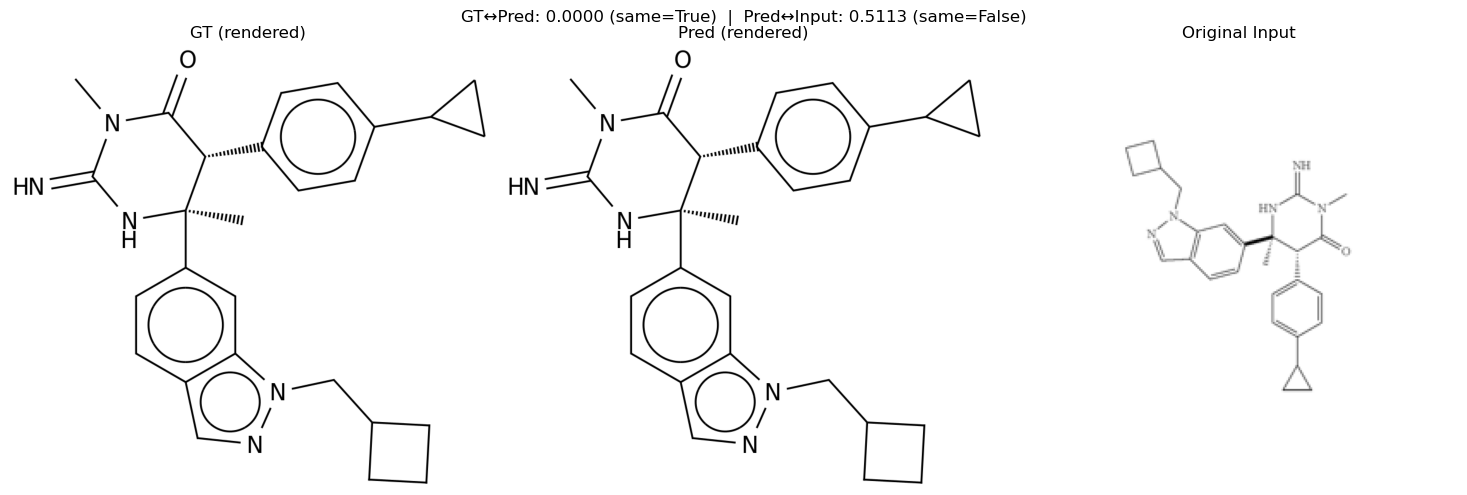

In [19]:
from MolDiscriminator_model import MoleculeDiscriminator
from drawing_engine import generate_image_from_smiles

# Load MolDiscriminator
discriminator = MoleculeDiscriminator(device=torch.device('cuda'))
discriminator.load_model(str(proj_dir / "MolScanner" / "models" / "MolDiscriminator" / "20260223_curriculum.pth"))

# Generate images from SMILES
gt_img, _, _, gt_success, _, _ = generate_image_from_smiles(ground_truth_smiles, mol_augment=False, default_drawing_style=True)
pred_img, _, _, pred_success, _, _ = generate_image_from_smiles(pred_smiles, mol_augment=False, default_drawing_style=True)
print(f"GT image generated: {gt_success}, Pred image generated: {pred_success}")

# Read the original input image (RGB)
original_input_img = cv2.cvtColor(cv2.imread(str(random_png)), cv2.COLOR_BGR2RGB)

# Compute embedding distances
is_same_gt_pred, dist_gt_pred = discriminator.predict(gt_img, pred_img)
is_same_pred_input, dist_pred_input = discriminator.predict(pred_img, original_input_img)
is_same_gt_input, dist_gt_input = discriminator.predict(gt_img, original_input_img)

print(f"GT rendered vs Pred rendered  — distance: {dist_gt_pred:.4f}, same: {is_same_gt_pred}")
print(f"Pred rendered vs Original input — distance: {dist_pred_input:.4f}, same: {is_same_pred_input}")
print(f"GT rendered vs Original input — distance: {dist_gt_input:.4f}, same: {is_same_gt_input}")

# Show all three images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_img)
axes[0].set_title('GT (rendered)')
axes[0].axis('off')
axes[1].imshow(pred_img)
axes[1].set_title('Pred (rendered)')
axes[1].axis('off')
axes[2].imshow(original_input_img)
axes[2].set_title('Original Input')
axes[2].axis('off')
plt.suptitle(f'GT↔Pred: {dist_gt_pred:.4f} (same={is_same_gt_pred})  |  Pred↔Input: {dist_pred_input:.4f} (same={is_same_pred_input})')
plt.tight_layout()
plt.show()

### To check if the benchmark itself is wrong

Label: CCOC(=O)CCC1=CC=C(C=C1C(F)(F)F)[C@@H]1CC(=O)CC1
Prediction: CCOC(=O)CCc1ccc([C@@H]2CCC(=O)C2)cc1C(F)(F)F


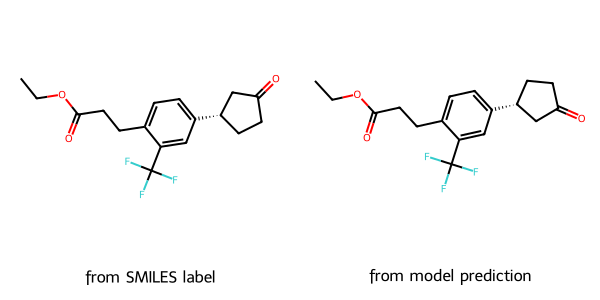

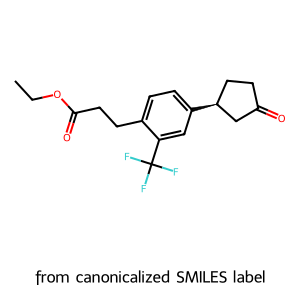

In [223]:
from rdkit import Chem
from rdkit.Chem import Draw

raw_gt_mol = Chem.MolFromSmiles(raw_ground_truth_smiles)
pred_mol = Chem.MolFromSmiles(pred_smiles)
print("Label:", raw_ground_truth_smiles)
print("Prediction:", pred_smiles)

img = Draw.MolsToGridImage([raw_gt_mol, pred_mol], 
                            molsPerRow=2, 
                            subImgSize=(300, 300),
                            legends=['from SMILES label', 'from model prediction'])

display(img)

gt_mol = Chem.MolFromSmiles(ground_truth_smiles)
img = Draw.MolsToImage([gt_mol], 
                       subImgSize=(300, 300),
                       legends=['from canonicalized SMILES label'])
display(img)

## Batch

In [ ]:
from MolScanner_model import MolScannerVocab, MolScannerModel, evaluate_benchmarks

vocab = MolScannerVocab(n_bins=64)
model = MolScannerModel(vocab=vocab, backbone='swin_b', pretrained=True)
checkpoint = 'best'
model.load_model(str(proj_dir / "MolScanner" / "models" / "MolScanner" / f"{checkpoint}.pth"), device='cuda')

benchmarks = [
    {'name': 'indigo', 'benchmark_dir': str(data_dir / "benchmark/synthetic/indigo"), 'csv_path': str(data_dir / "benchmark/synthetic/indigo.csv")},
    {'name': 'chemdraw', 'benchmark_dir': str(data_dir / "benchmark/synthetic/chemdraw"), 'csv_path': str(data_dir / "benchmark/synthetic/chemdraw.csv")},
    {'name': 'CLEF',  'benchmark_dir': str(data_dir / "benchmark/real/CLEF"),  'csv_path': str(data_dir / "benchmark/real/CLEF.csv")},
    {'name': 'UOB',   'benchmark_dir': str(data_dir / "benchmark/real/UOB"),   'csv_path': str(data_dir / "benchmark/real/UOB.csv")},
    {'name': 'USPTO', 'benchmark_dir': str(data_dir / "benchmark/real/USPTO"), 'csv_path': str(data_dir / "benchmark/real/USPTO.csv")},
    {'name': 'staker', 'benchmark_dir': str(data_dir / "benchmark/real/staker"), 'csv_path': str(data_dir / "benchmark/real/staker.csv")},
    {'name': 'acs',   'benchmark_dir': str(data_dir / "benchmark/real/acs"),   'csv_path': str(data_dir / "benchmark/real/acs.csv")},
]

results = evaluate_benchmarks(model, benchmarks, beam_size=1)

Model loaded from: /home/zqlyu2/projects/Markush/MolScanner/models/MolScanner/best.pth

Benchmark: indigo
  Images: 5719
Distributing 5719 images across 4 GPUs...


GPU-0: 100%|██████████| 12/12 [09:51<00:00, 49.26s/it]


  Post-processing [decoder] ...


  decoder: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:00<00:00, 283573.80it/s]


  [indigo/decoder    ] Exact Match: 87.71% Tanimoto: 0.9926  Failed: 31
  Post-processing [graph] ...


...

  graph: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:00<00:00, 217733.14it/s]


  [USPTO/graph      ] Exact Match: 74.33% Tanimoto: 0.8527  Failed: 585
  Post-processing [postprocess] ...


  postprocess: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 5719/5719 [00:06<00:00, 893.57it/s]


  [USPTO/postprocess] Exact Match: 76.61% Tanimoto: 0.8820  Failed: 391

Benchmark: staker
  Images: 50000
Distributing 50000 images across 4 GPUs...


GPU-0:  41%|████      | 40/98 [28:46<40:51, 42.26s/it]  